In [10]:
import nugget
import numpy as np
import importlib
import pickle
import torch

In [11]:
device = None
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(device=device, use_poisson=False, domain_size=2500)
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate

In [12]:
importlib.reload(nugget.utils.basic_evaluator)
importlib.reload(nugget.utils.vis_tools)
importlib.reload(nugget.geometries.EvanescentString)
geometry = nugget.geometries.EvanescentString.EvanescentString(
            device=device,
            hex_type='hexagonal',
            domain_size=1200,  # Size of detector domain
            dim=3,  # 3D geometry
            n_strings=70,  # Initial number of detector strings (ignore)
            points_per_string=20,  # Number of OMs per string
            custom_z_spacing=50, # OM spacing along string
            starting_weight =1000,
            active_weights_mode=True
        )

visualizer = nugget.utils.vis_tools.Visualizer(
    device=device,
    dim=3, 
    domain_size=2500,
    )

evaluator = nugget.utils.basic_evaluator.Evaluator(
    device=device,
    geometry=geometry,
    visualizer=visualizer,
)

In [13]:
test_signal_events = pickle.load(open('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_10000_r600_50_1.pkl', 'rb'))

In [60]:
importlib.reload(nugget.losses.geometry_penalties)
importlib.reload(nugget.losses.fisher_info)
rov_penalty = nugget.losses.geometry_penalties.ROVPenalty(
    device=geometry.device, 
    rov_rec_width=230,  # ROV dimensions
    rov_height=159.9, 
    rov_tri_length=159.9
)

angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=geometry.device,
    # device="cuda:3",
    resolution_type='angular',
    fisher_info_params=['position','energy', 'direction']
)


loss_params ={
    'num_angles': 360,  # Number of angles (divided into 360 degrees) to test for rov
    'num_events':10000,
    'signal_surrogate_func': light_yield_surrogate,
    'signal_event_params': test_signal_events,
    # 'fisher_info_params': ['position','energy', 'direction'],
    # 'fisher_info_grad_chunk_size': 7,  # Chunk size for computing gradients of Fisher information (adjust based on memory)
    # 'fisher_info_jacrev_chunk_size': 50000,  # Chunk size for computing Jacobians of Fisher information (adjust based on memory)
    # 'fisher_info_point_chunk_size': 70000,  # Chunk size for processing events when computing Fisher information (adjust based on memory)
    # 'fisher_info_llr_autodiff_mode': 'jvp',  # Method for computing gradients of log-likelihood ratio ('grad' or 'jacrev')
}

loss_func_dict = {
    # 'rov_penalty': rov_penalty,
    'angular_resolution_loss': angular_resolution_loss,
}

plot_types = [
    'string_xy',
    # 'string_xy_rov_penalty',
    'angular_resolution_vs_energy',
]

vis_kwargs = {
    'plot_types': plot_types,
    'zoom_range':900,
    'show_resolution_ci':True,
    # 'rov_penalty_func': rov_penalty,
    'rov_draw_safe_space_on_violations':False,
    'n_zenith_bins': 10,  # Binning for angular resolution plots
    'n_energy_bins': 10,   # Binning for energy resolution plots
    'resolution_logy': True,  # Whether to use log scale for resolution plots,
    'resolution_stat': 'mean',  # Statistic to plot for resolution ('median' or 'mean')
    'min_angular_resolution': 0.004,  # Minimum angular resolution to display (degrees)
    'max_angular_resolution': np.pi*2,  # Maximum angular resolution to display (degrees)
    
}

In [61]:
geom_dicts = {}
loss_param_dicts = {}
for geom_name in ['600hexagon','default', 'expanded', 'modified', 'large', '800main']:
    if geom_name != '800main' and geom_name != '600hexagon':
        geom_dict = {'string_xy': np.load(f'../other/{geom_name}_xy.npy')}
    elif geom_name == '800main':
        geom_dict = pickle.load(open('600main_r600_50_1_ang_res/geom_16.pkl', 'rb'))
    elif geom_name == '600hexagon':
        geom_dict = {'n_strings': 70}
    geom_dicts[geom_name] = geom_dict
    # IMPORTANT: copy loss_params per-geometry so we don't overwrite the same dict
    loss_param_dicts[geom_name] = dict(loss_params)
    loss_param_dicts[geom_name]['precomputed_fisher_info_per_string_per_event'] = torch.load(
        f'res_test/fisher_info_per_string_per_event_10000_{geom_name}_r600_50_1.pt'
    )

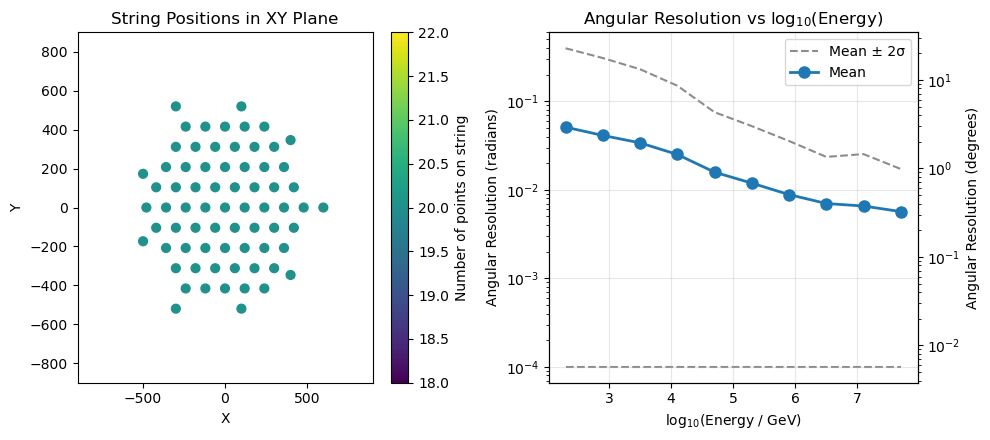

Eval | angular_resolution_loss: 0.00655639


In [20]:
results = evaluator.evaluate(
    geom_dict=geom_dicts['600hexagon'],
    loss_func_dict=loss_func_dict,
    loss_params_dict=loss_param_dicts['600hexagon'],
    vis_kwargs=vis_kwargs,
    visualize=True,
)

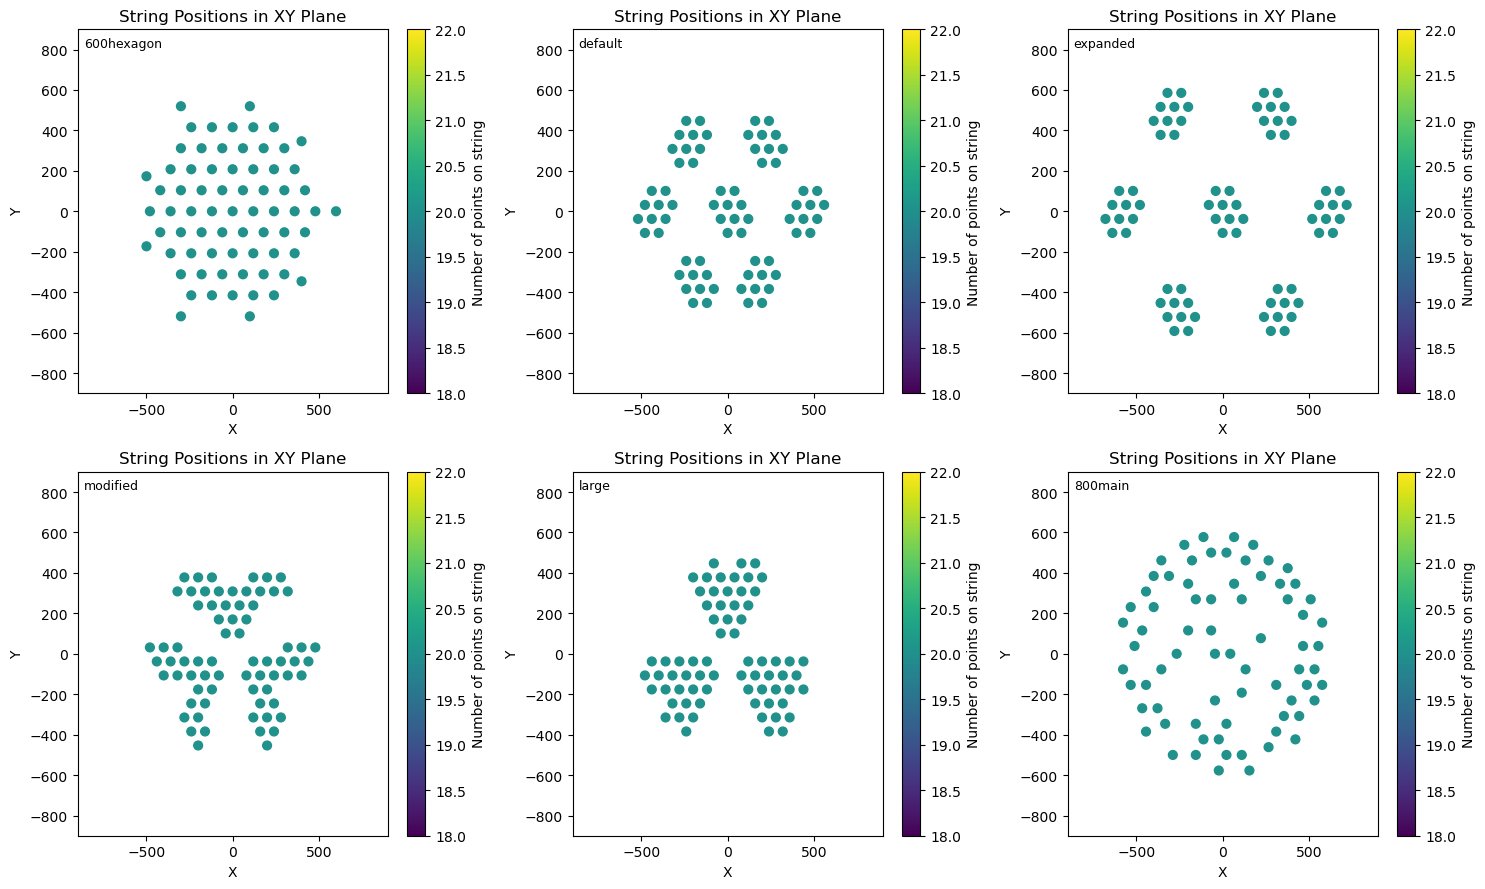

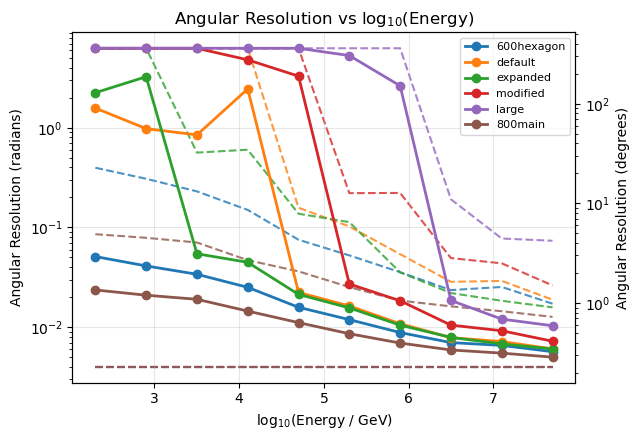

In [62]:
result =evaluator.evaluate_multi(
    geom_dicts=geom_dicts,
    loss_func_dict=loss_func_dict,
    loss_params_dicts=loss_param_dicts,
    vis_kwargs=vis_kwargs,
    visualize=True,
)